# GAMs to Predict TAVG PC Coefficients from Geography

Use PCA of yearly TAVG (temperature) profiles. Predict PC1, PC2, PC3 from latitude, distance to coast, longitude, and elevation. Start with visualizing the PCA structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dask.dataframe as dd
import pickle
from pathlib import Path
from pygam import LinearGAM, s, l
import warnings
warnings.filterwarnings('ignore')

# SciPy 2.0+ compatibility for pygam
import scipy.sparse as sp
if not hasattr(sp.csr_matrix, 'A'):
    sp.csr_matrix.A = property(lambda self: self.toarray())
if not hasattr(sp.csc_matrix, 'A'):
    sp.csc_matrix.A = property(lambda self: self.toarray())

PCA_PATH = Path('/home/yfreund/dask-CSE255/weather/weather_info/pca_results/tavg_pca_results.pkl')
DATA_PATH = '/home/yfreund/weather_data/stations_weather_with_dist2coast.parquet'

In [2]:
with open(PCA_PATH, 'rb') as f:
    pca_results = pickle.load(f)

pca_mean = pca_results['mean']
pca_components = pca_results['components']
evr = pca_results['explained_variance_ratios']

print(f"Mean shape: {pca_mean.shape}")
print(f"Components shape: {pca_components.shape}")
print(f"Top 3 variance ratios: {evr[:3]}")
print(f"Top 3 %: {[f'{r*100:.2f}%' for r in evr[:3]]}")

Mean shape: (365,)
Components shape: (10, 365)
Top 3 variance ratios: [0.7612647  0.16507481 0.02691134]
Top 3 %: ['76.13%', '16.51%', '2.69%']


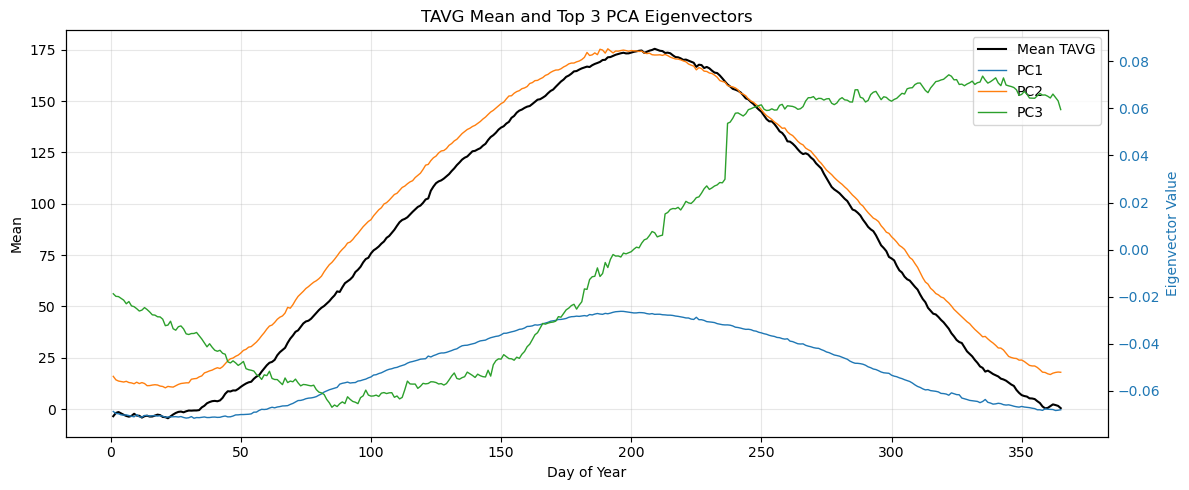

In [3]:
fig, ax_mean = plt.subplots(figsize=(12, 5))
days = np.arange(1, 366)

line_mean, = ax_mean.plot(days, pca_mean, color='black', linewidth=1.5, label='Mean TAVG')
ax_mean.set_xlabel('Day of Year')
ax_mean.set_ylabel('Mean', color='black')
ax_mean.tick_params(axis='y', labelcolor='black')
ax_mean.grid(True, alpha=0.3)

ax_pc = ax_mean.twinx()
pc_colors = ['tab:blue', 'tab:orange', 'tab:green']
pc_lines = []
for idx, color in enumerate(pc_colors):
    line, = ax_pc.plot(days, pca_components[idx], color=color, linewidth=1.0, label=f'PC{idx+1}')
    pc_lines.append(line)

ax_pc.set_ylabel('Eigenvector Value', color='tab:blue')
ax_pc.tick_params(axis='y', labelcolor='tab:blue')

lines = [line_mean] + pc_lines
labels = [l.get_label() for l in lines]
ax_mean.legend(lines, labels, loc='upper right')
ax_mean.set_title('TAVG Mean and Top 3 PCA Eigenvectors')
plt.tight_layout()
plt.show()

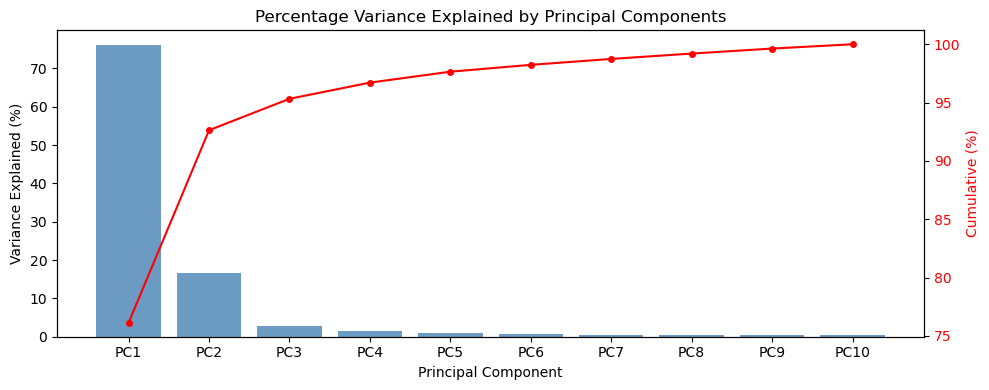

In [4]:
n_pcs = min(10, len(evr))
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(1, n_pcs + 1)
ax.bar(x, evr[:n_pcs] * 100, color='steelblue', alpha=0.8)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_xticks(x)
ax.set_xticklabels([f'PC{i}' for i in x])
ax.set_title('Percentage Variance Explained by Principal Components')
ax2 = ax.twinx()
ax2.plot(x, np.cumsum(evr[:n_pcs]) * 100, 'ro-', markersize=4, label='Cumulative')
ax2.set_ylabel('Cumulative (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.tight_layout()
plt.show()

In [5]:
df = dd.read_parquet(DATA_PATH)
tavg = df[df['ELEMENT'] == 'TAVG'].compute()

daily_cols = [f'day_{i}' for i in range(1, 366)]
daily_values = np.nan_to_num(tavg[daily_cols].values, nan=0.0)
normalized = daily_values - pca_mean[np.newaxis, :]

tavg = tavg.copy()
for i in range(3):
    tavg[f'PC{i+1}'] = normalized @ pca_components[i]

print(f"TAVG rows: {len(tavg)}")
print(tavg[['PC1','PC2','PC3']].describe())

TAVG rows: 295949
                PC1           PC2           PC3
count  2.959490e+05  2.959490e+05  2.959490e+05
mean  -8.260618e-15 -8.998174e-15 -6.767069e-15
std    1.841651e+03  8.575903e+02  3.462638e+02
min   -1.937431e+04 -7.680075e+03 -1.735741e+04
25%   -1.238753e+03 -3.858514e+02 -1.247282e+02
50%    2.666287e+02  1.341240e+02  8.560919e+00
75%    1.190215e+03  5.974989e+02  1.557337e+02
max    1.107798e+04  1.242397e+04  1.376278e+04


In [6]:
if 'dist_to_coast' not in tavg.columns and 'dist_to_water_m' in tavg.columns:
    tavg = tavg.rename(columns={'dist_to_water_m': 'dist_to_coast'})
elif 'dist_to_coast' not in tavg.columns:
    tavg['dist_to_coast'] = 0.0

agg = tavg.groupby('ID').agg({
    'latitude': 'first', 'longitude': 'first', 'elevation': 'first',
    'dist_to_coast': 'first', 'PC1': 'mean', 'PC2': 'mean', 'PC3': 'mean'
}).reset_index()

agg = agg.dropna(subset=['latitude','longitude','elevation','dist_to_coast','PC1','PC2','PC3'])
agg = agg[agg['elevation'] >= 0]

print(f"Stations: {len(agg)}")
print(agg[['latitude','longitude','elevation','dist_to_coast','PC1','PC2','PC3']].describe())

Stations: 9395
          latitude    longitude    elevation  dist_to_coast          PC1  \
count  9395.000000  9395.000000  9395.000000    9395.000000  9395.000000   
mean     35.884147   -28.399359   646.128898     450.097158    89.698732   
std      24.794947    89.782885   814.466838     477.939980  1537.587713   
min     -89.000000  -179.994700     0.000000       0.000828 -4156.113153   
25%      33.036700  -110.910000    68.000000      39.584100  -931.604654   
50%      42.410000   -66.010600   273.000000     288.344000   316.920124   
75%      49.591650    43.558500   927.000000     727.445000  1073.929682   
max      83.650000   179.320000  5033.000000    2488.100000  9733.140247   

               PC2          PC3  
count  9395.000000  9395.000000  
mean    -95.818568     3.465992  
std     715.021374   146.760454  
min   -6378.146946 -1011.391817  
25%    -426.775070   -80.970655  
50%       0.949213    -8.318285  
75%     388.694387    83.858086  
max    1851.241004  1131.588

In [15]:
predictor_cols = ['latitude', 'dist_to_coast', 'elevation']
X = agg[predictor_cols].to_numpy(dtype=float)

n = len(X)
if n > 50000:
    rng = np.random.default_rng(42)
    idx = rng.choice(n, 50000, replace=False)
    X = X[idx]
    agg_sub = agg.iloc[idx]
else:
    agg_sub = agg

y1 = agg_sub['PC1'].to_numpy(dtype=float)
y2 = agg_sub['PC2'].to_numpy(dtype=float)
y3 = agg_sub['PC3'].to_numpy(dtype=float)

print(f"X shape: {X.shape}")
print(f"PC1 range: [{y1.min():.2f}, {y1.max():.2f}]")
print(f"PC2 range: [{y2.min():.2f}, {y2.max():.2f}]")
print(f"PC3 range: [{y3.min():.2f}, {y3.max():.2f}]")

X shape: (9395, 3)
PC1 range: [-4156.11, 9733.14]
PC2 range: [-6378.15, 1851.24]
PC3 range: [-1011.39, 1131.59]


In [18]:
gam1 = LinearGAM(s(0, n_splines=20) + s(1, n_splines=20) + s(2, n_splines=20)).gridsearch(X, y1, progress=False)
gam2 = LinearGAM(s(0, n_splines=20) + s(1, n_splines=20) + s(2, n_splines=20)).gridsearch(X, y2, progress=False)
gam3 = LinearGAM(s(0, n_splines=20) + s(1, n_splines=20) + s(2, n_splines=20)).gridsearch(X, y3, progress=False)
print("Chosen lambdas (PC1):", gam1.lam)
print("Chosen lambdas (PC2):", gam2.lam)
print("Chosen lambdas (PC3):", gam3.lam)

print('PC1:'); gam1.summary()
print('\nPC2:'); gam2.summary()
print('\nPC3:'); gam3.summary()

Chosen lambdas (PC1): [[1.0], [1.0], [1.0]]
Chosen lambdas (PC2): [[1.0], [1.0], [1.0]]
Chosen lambdas (PC3): [[0.25118864315095796], [0.25118864315095796], [0.25118864315095796]]
PC1:
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      42.679
Link Function:                     IdentityLink Log Likelihood:                                -132782.682
Number of Samples:                         9395 AIC:                                            265652.722
                                                AICc:                                          265653.1394
                                                GCV:                                           552717.7313
                                                Scale:            

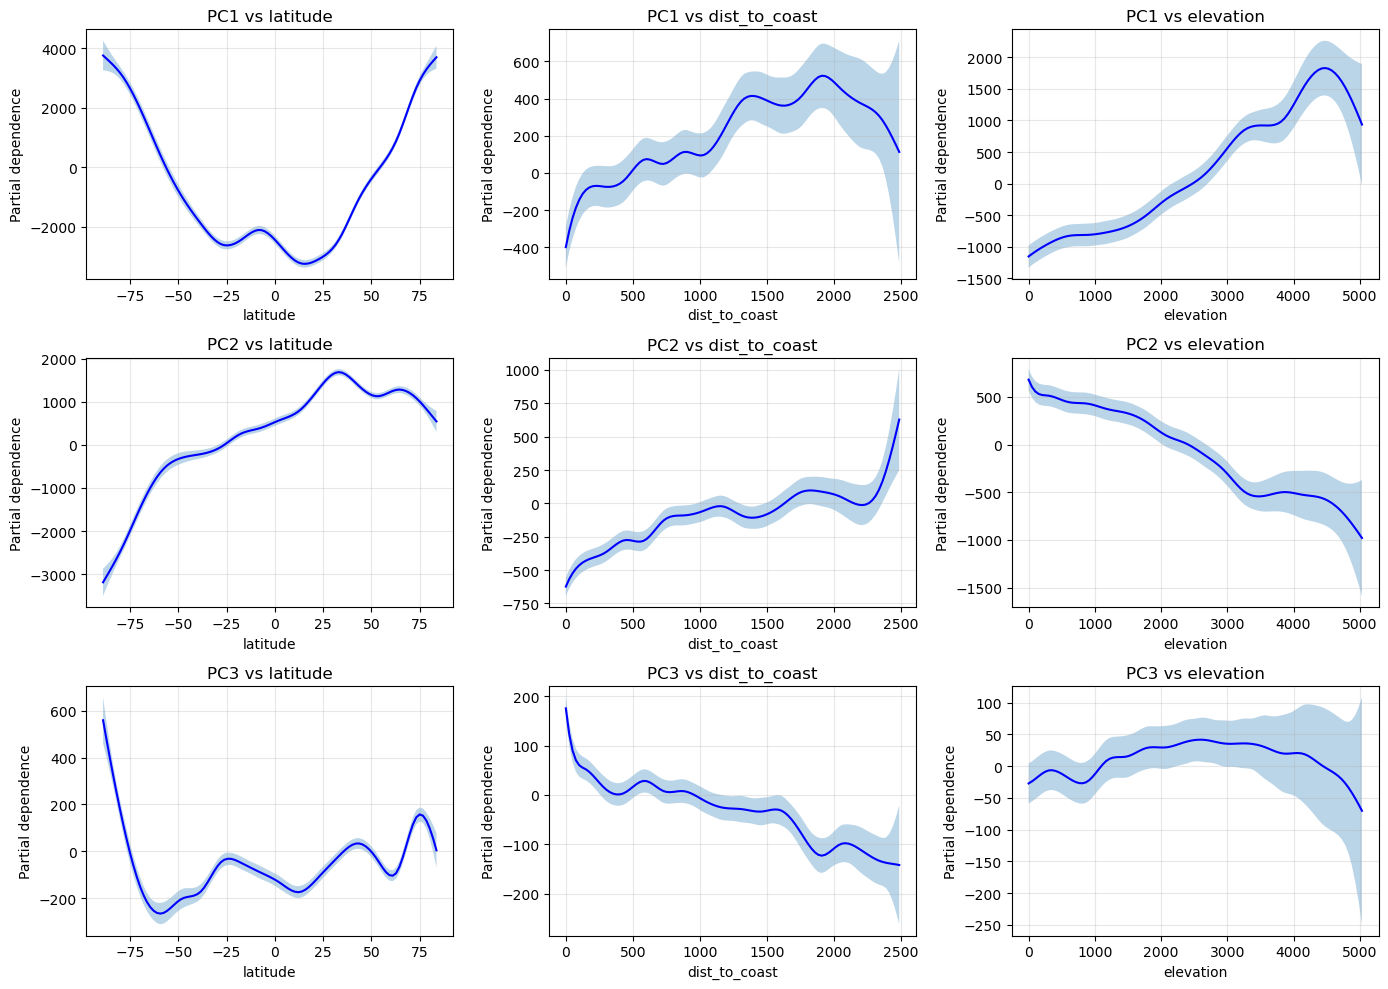

In [19]:
gams = [gam1, gam2, gam3]
pc_names = ['PC1','PC2','PC3']
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for row, (gam, name) in enumerate(zip(gams, pc_names)):
    for term in range(3):
        ax = axes[row, term]
        XX = gam.generate_X_grid(term=term, n=100)
        pdep, confi = gam.partial_dependence(term=term, X=XX, width=0.95)
        ax.plot(XX[:, term], pdep, 'b-')
        ax.fill_between(XX[:, term], confi[:, 0], confi[:, 1], alpha=0.3)
        ax.set_xlabel(predictor_cols[term])
        ax.set_ylabel('Partial dependence')
        ax.set_title(f'{name} vs {predictor_cols[term]}')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
results = []
for gam, name, y in zip(gams, pc_names, [y1, y2, y3]):
    y_pred = gam.predict(X)
    r2 = gam.statistics_.get('pseudo_r2', {})
    r2_val = list(r2.values())[0] if r2 else np.nan
    mae = np.mean(np.abs(y - y_pred))
    rmse = np.sqrt(np.mean((y - y_pred)**2))
    aic = gam.statistics_.get('AIC', np.nan)
    results.append({'Model': name, 'R2': r2_val, 'MAE': mae, 'RMSE': rmse, 'AIC': aic})

tab = pd.DataFrame(results)
print(tab.to_string(index=False))

Model       R2        MAE       RMSE           AIC
  PC1 0.769151 531.452464 738.721669 265652.721995
  PC2 0.571847 333.286093 467.837735 248486.221992
  PC3 0.327071  87.539081 120.384495 197496.734268


### Akaike Information Criterion (AIC)

**AIC** estimates how much information is lost when a model is used to approximate the true data-generating process. It balances model fit with model complexity.

**Formula:** AIC = 2k − 2 ln(L̂)

- **k** = number of parameters in the model  
- **L̂** = maximized value of the likelihood function  

Equivalently: AIC = D + 2k, where D = −2 ln(L̂) is the deviance.

**Interpretation:**
- The **−2 ln(L̂)** term measures lack of fit (larger = worse fit)
- The **2k** term penalizes complexity (more parameters)
- **Lower AIC is better** — it favors a good fit without overfitting

When comparing models, differences in AIC > 2 are often meaningful; differences > 6 indicate strong preference for the lower-AIC model.

## Goodness of Fit

| Column | Description |
|--------|-------------|
| **Model** | Which PC coefficient is predicted (PC1, PC2, or PC3). |
| **R²** | Pseudo R² (deviance explained). Fraction of variance in the response accounted for by the model. Higher means better fit. |
| **MAE** | Mean Absolute Error: average of abs(observed − predicted). Lower is better; in same units as the PC coefficient. |
| **RMSE** | Root Mean Squared Error: √(mean of squared residuals). Penalizes large errors more than MAE. Lower is better. |
| **AIC** | Akaike Information Criterion. Balances fit vs. complexity; lower is better when comparing models. |